<a href="https://colab.research.google.com/github/Double-El/future_academy/blob/unsupervised/unsupervised_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving df_combined.xlsx to df_combined (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('df_combined.xlsx')

df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,...,col2_emb_374,col2_emb_375,col2_emb_376,col2_emb_377,col2_emb_378,col2_emb_379,col2_emb_380,col2_emb_381,col2_emb_382,col2_emb_383
0,1,34,4,98,2020,5.0,12,93.0,NaN,1,...,0.094688,-0.110139,0.123232,-0.022907,-0.046199,0.120761,-0.026884,0.093468,0.020847,0.153500
1,0,27,2,94,2019,4.8,30,NaN,NaN,0,...,0.231876,-0.185643,-0.056941,0.241551,-0.194306,0.216554,-0.155096,-0.036695,-0.214479,0.223178
2,0,30,1,98,2020,4.4,44,NaN,NaN,0,...,0.033288,-0.034485,0.100701,-0.147256,0.037535,0.288588,-0.056828,0.375191,-0.186413,0.065238
3,0,25,2,72,2022,5.0,16,NaN,NaN,0,...,0.154946,-0.034820,0.030083,-0.056413,-0.138814,0.064954,0.018353,-0.080310,0.109010,0.051234
4,1,32,5,76,2021,3.9,36,79.0,NaN,1,...,0.026167,0.060451,0.283615,-0.162884,0.086377,0.185026,0.008406,0.217604,-0.025841,0.064456


In [ ]:
# df.info() 실행시 컬럼이 너무 많아 생략되는 경우 설정 변경
pd.set_option('display.max_info_columns', 10)  # 원하는 숫자로 조절
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Columns: 783 entries, position to col2_emb_383
dtypes: float64(771), int64(10), object(2)
memory usage: 226.5+ KB


In [ ]:
df_object = df.select_dtypes(include='object')
df_object.head()

,profile,episode
0,"구민준 대리는 Tech운영부에서 근무하며, 대학 시절 통계학을 전공하며 데이터 기반...",대리 구민준은(는) 고객 불만 접수 시스템 개편 TF에 참여하여 민원 처리 속도 향...
1,"김수진 행원는 글로벌서비스개발부에서 근무하며, 고객 상담 경험을 토대로 서비스 설계...",행원 김수진은(는) 지점 실적이 하락하던 시기에 지역 특화 마케팅 아이디어를 제안해...
2,"김애은 행원는 금융서비스개발부에서 근무하며, 스타트업 근무 경험을 살려 유연한 사고...",행원 김애은은(는) 외국인 고객 응대 시 자발적으로 영어 안내문을 제작해 팀의 대응...
3,"김여리 행원는 Tech운영부에서 근무하며, 지방 영업점에서 경력을 시작해 고객 중심...",행원 김여리은(는) RPA를 도입한 업무 자동화 프로젝트로 연간 수백 건의 수작업을...
4,"김연지 대리는 자금세탁방지부에서 근무하며, IT 전환 프로젝트에 초기부터 참여하며 ...",대리 김연지은(는) 데이터 시각화 교육을 수료하고 실무에 적용해 보고서 품질을 높였다.


In [ ]:
df = df.drop(['profile', 'episode'], axis=1)

""
0
1
2
3
4


In [ ]:
# 수치형이 아닌 자료형이 있는지 확인
df_non_numeric = df.select_dtypes(exclude='number')
print("수치형이 아닌 컬럼들:", df_non_numeric.columns.tolist())


수치형이 아닌 컬럼들: []


In [ ]:
# 자료형별 전체 분포확인
print(df.dtypes.value_counts())


float64    771
int64       10
Name: count, dtype: int64


In [ ]:
missing_cols = df.columns[df.isnull().any()].tolist()
print(" 결측치가 있는 컬럼:", missing_cols)


 결측치가 있는 컬럼: ['leadership_score', 'team_size']


In [ ]:
# 컬럼명이 많으므로 앞의 20만 확인
print(df.columns[:20])

Index(['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints', 'leadership_score', 'team_size', 'is_mentor',
       'gender_male', 'gender_female', 'cluster', 'col1_emb_0', 'col1_emb_1',
       'col1_emb_2', 'col1_emb_3', 'col1_emb_4', 'col1_emb_5', 'col1_emb_6'],
      dtype='object')


In [ ]:
# 비정형데이터에 대한 클러스터값들이 포함된 컬럼을 삭제
df = df.drop('cluster', axis=1)
print(df.columns[:20])

Index(['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints', 'leadership_score', 'team_size', 'is_mentor',
       'gender_male', 'gender_female', 'col1_emb_0', 'col1_emb_1',
       'col1_emb_2', 'col1_emb_3', 'col1_emb_4', 'col1_emb_5', 'col1_emb_6',
       'col1_emb_7'],
      dtype='object')


In [ ]:
# 결측치가 있는 컬럼을 다른 특성을 고려한 다변량 대치법(MICE)로 채운다.
# 참고하고자 하는 컬럼을 직접 지정. 비정형데이터 컬럼은 참고하지 않음.
target_cols = ['leadership_score', 'team_size']  # 결측치를 채우고 싶은 컬럼
ref_cols = ['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints','is_mentor',
       'gender_male', 'gender_female']  # 참고할 컬럼


# 대치에 사용할 전체 컬럼 리스트 (순서 중요 없음)
all_cols = ref_cols + target_cols

# 선택한 컬럼으로 구성된 서브 DataFrame
impute_df = df[all_cols]

# Iterative Imputer 정의 (회귀 기반)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(),
    max_iter=10,
    random_state=42
)

# 대치 실행
imputed_result = imputer.fit_transform(impute_df)

# DataFrame으로 변환
imputed_df = pd.DataFrame(imputed_result, columns=all_cols)

# 대치된 값만 원래 df에 반영
for col in target_cols:
    df[col] = imputed_df[col]

# 확인
print("결측치 처리 완료 여부:")
print(df[target_cols].isnull().sum())


결측치 처리 완료 여부:
leadership_score    0
team_size           0
dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


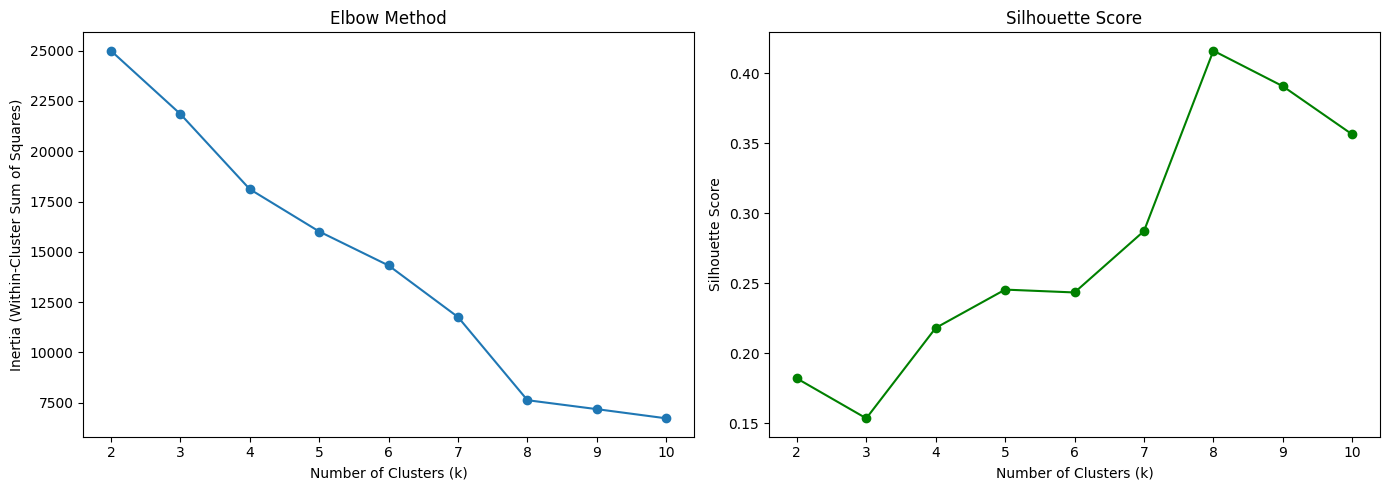

In [ ]:
# 클러스터링에서 적절한 군집수를 결정하기 위해 elbow method 와 silhouette score 활용
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# 1. 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. Elbow & Silhouette 시각화
inertias = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)  # inertia: 군집 내 거리 제곱합
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 3. 그래프 그리기
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax[0].plot(K, inertias, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

# Silhouette Score
ax[1].plot(K, silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [ ]:
# 데이터포인터들이 클러스터링 갯수가 8개일 때 가장 잘 분리되는 것으로 보여 8개군으로 가상인물 분류
# 실루엣 스코어가 가장 높으나 해당범위가 0.416 정도로 군집이 다소 겹칠 수 있음.
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: 실루엣 스코어 = {score:.3f}")


k=2: 실루엣 스코어 = 0.133
k=3: 실루엣 스코어 = 0.150
k=4: 실루엣 스코어 = 0.177
k=5: 실루엣 스코어 = 0.265
k=6: 실루엣 스코어 = 0.310
k=7: 실루엣 스코어 = 0.370
k=8: 실루엣 스코어 = 0.416
k=9: 실루엣 스코어 = 0.377


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 수치형 데이터만 추출
df_numeric = df.select_dtypes(include='number')

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# 3. KMeans 클러스터링 (k=8)
kmeans = KMeans(n_clusters=8, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 4. 군집별 주요 특성 요약 (평균값 기준)
summary = df.groupby('cluster').mean(numeric_only=True).round(2)

print("군집별 주요 특성 요약:")
print(summary.iloc[:, :12]) # 앞의 12개 컬럼만 확인


군집별 주요 특성 요약:
         position    age  years_at_company  performance_score  \
cluster                                                         
0            0.00  30.25              2.00              83.50   
1            0.75  30.75              3.75              85.25   
2            0.60  32.00              3.80              83.20   
3            1.60  38.60              7.20              85.20   
4            0.40  30.00              2.80              88.60   
5            0.80  32.60              4.20              85.40   
6            0.40  31.00              2.80              82.20   
7            1.50  35.75              7.00              87.00   

         last_promotion_year  customer_satisfaction_avg  \
cluster                                                   
0                    2021.50                       4.25   
1                    2020.75                       3.82   
2                    2021.40                       4.62   
3                    2020.20            

<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-21-f43a29994dba>:12: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layo

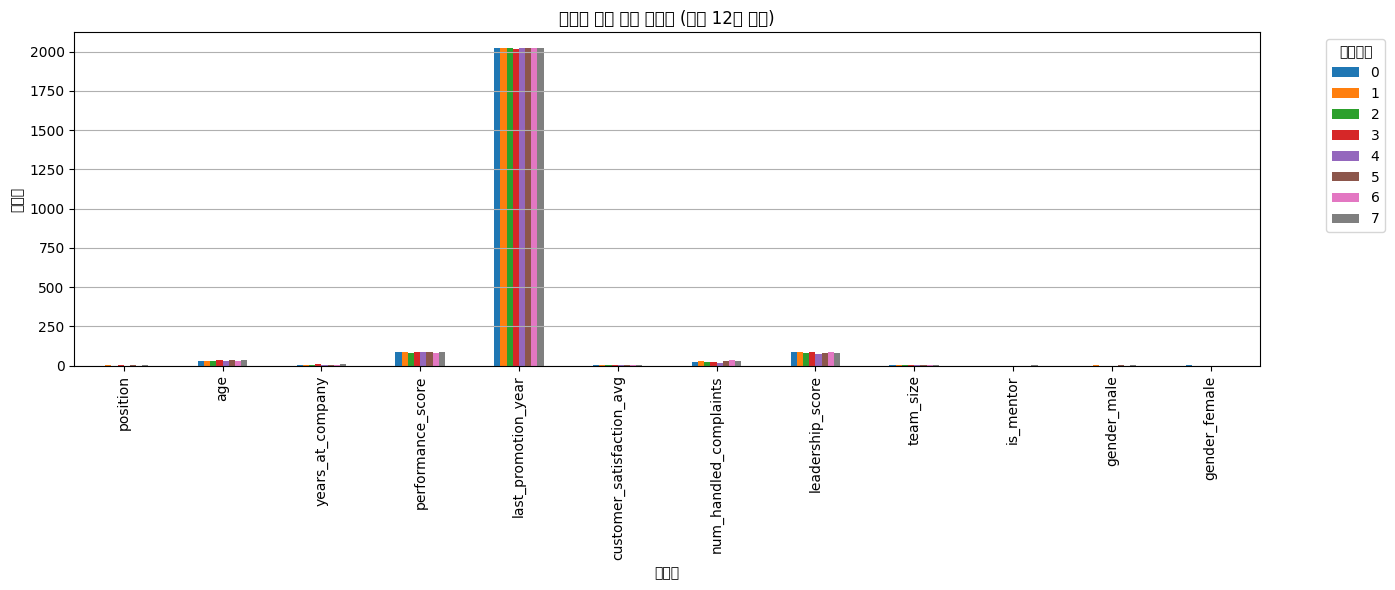

In [ ]:
import matplotlib.pyplot as plt

# 1. 군집별 평균값 (앞의 12개 컬럼만)
summary = df.groupby('cluster').mean(numeric_only=True).round(2).iloc[:, :12]

# 2. 시각화
summary.T.plot(kind='bar', figsize=(14, 6))
plt.title('군집별 주요 특성 평균값 (상위 12개 컬럼)')
plt.xlabel('특성명')
plt.ylabel('평균값')
plt.legend(title='클러스터', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [ ]:
import plotly.graph_objects as go

# 1. 군집별 평균값 요약 (상위 12개 컬럼만 사용)
summary = df.groupby('cluster').mean(numeric_only=True).round(2).iloc[:, :12]
categories = summary.columns.tolist()

# 2. Plotly 레이더 차트 생성
fig = go.Figure()

for i in range(summary.shape[0]):  # 각 군집에 대해
    fig.add_trace(go.Scatterpolar(
        r=summary.iloc[i].values.tolist() + [summary.iloc[i].values[0]],  # 닫기용 반복
        theta=categories + [categories[0]],
        fill='toself',
        name=f'Cluster {i}'
    ))

# 3. 레이아웃 설정
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True)
    ),
    title="군집별 주요 특성 Radar Chart (Plotly)",
    showlegend=True,
    width=800,
    height=700
)

# 4. 출력
fig.show()


In [ ]:
# 군집 간 특성이 전혀 구별되지 않는 상황으로 스케일 문제와 정보량이 낮은 변수가 많아 데이터 업로드 부터 다시 시작
from google.colab import files

uploaded = files.upload()

Saving df_combined.xlsx to df_combined (2).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('df_combined.xlsx')

df.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,...,col2_emb_374,col2_emb_375,col2_emb_376,col2_emb_377,col2_emb_378,col2_emb_379,col2_emb_380,col2_emb_381,col2_emb_382,col2_emb_383
0,1,34,4,98,2020,5.0,12,93.0,NaN,1,...,0.094688,-0.110139,0.123232,-0.022907,-0.046199,0.120761,-0.026884,0.093468,0.020847,0.153500
1,0,27,2,94,2019,4.8,30,NaN,NaN,0,...,0.231876,-0.185643,-0.056941,0.241551,-0.194306,0.216554,-0.155096,-0.036695,-0.214479,0.223178
2,0,30,1,98,2020,4.4,44,NaN,NaN,0,...,0.033288,-0.034485,0.100701,-0.147256,0.037535,0.288588,-0.056828,0.375191,-0.186413,0.065238
3,0,25,2,72,2022,5.0,16,NaN,NaN,0,...,0.154946,-0.034820,0.030083,-0.056413,-0.138814,0.064954,0.018353,-0.080310,0.109010,0.051234
4,1,32,5,76,2021,3.9,36,79.0,NaN,1,...,0.026167,0.060451,0.283615,-0.162884,0.086377,0.185026,0.008406,0.217604,-0.025841,0.064456


In [ ]:
df = df.drop(['profile', 'episode'], axis=1)

In [ ]:
df = df.drop('cluster', axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include='number').columns

# 2. MinMaxScaler 적용
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 3. 결과 확인
print(df_scaled.head())


   position       age  years_at_company  performance_score  \
0  0.333333  0.428571          0.214286           0.965517   
1  0.000000  0.095238          0.071429           0.827586   
2  0.000000  0.238095          0.000000           0.965517   
3  0.000000  0.000000          0.071429           0.068966   
4  0.333333  0.333333          0.285714           0.206897   

   last_promotion_year  customer_satisfaction_avg  num_handled_complaints  \
0                 0.25                   1.000000                0.136364   
1                 0.00                   0.866667                0.545455   
2                 0.25                   0.600000                0.863636   
3                 0.75                   1.000000                0.227273   
4                 0.50                   0.266667                0.681818   

   leadership_score  team_size  is_mentor  ...  col2_emb_374  col2_emb_375  \
0          0.868421        NaN        1.0  ...      0.475931      0.362444   
1       

In [ ]:
# 결측치가 있는 컬럼을 다른 특성을 고려한 다변량 대치법(MICE)로 채운다.
# 참고하고자 하는 컬럼을 직접 지정. 비정형데이터 컬럼은 참고하지 않음.
target_cols = ['leadership_score', 'team_size']  # 결측치를 채우고 싶은 컬럼
ref_cols = ['position', 'age', 'years_at_company', 'performance_score',
       'last_promotion_year', 'customer_satisfaction_avg',
       'num_handled_complaints','is_mentor',
       'gender_male', 'gender_female']  # 참고할 컬럼


# 대치에 사용할 전체 컬럼 리스트 (순서 중요 없음)
all_cols = ref_cols + target_cols

# 선택한 컬럼으로 구성된 서브 DataFrame
impute_df = df_scaled[all_cols]

# Iterative Imputer 정의 (회귀 기반)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(),
    max_iter=10,
    random_state=42
)

# 대치 실행
imputed_result = imputer.fit_transform(impute_df)

# DataFrame으로 변환
imputed_df = pd.DataFrame(imputed_result, columns=all_cols)

# 대치된 값만 원래 df에 반영
for col in target_cols:
    df_scaled[col] = imputed_df[col]

# 확인
print("결측치 처리 완료 여부:")
print(df_scaled[target_cols].isnull().sum())


결측치 처리 완료 여부:
leadership_score    0
team_size           0
dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning:

[IterativeImputer] Early stopping criterion not reached.



In [ ]:
# 트리기반 모델로 정보량이 높은 중요 변수 추출은 target(정답)이 있는 경우 활용
# 가장 간단하고 효과적인 분산기반 필터링을 통해 중요 변수 추출

from sklearn.feature_selection import VarianceThreshold

# 수치형 컬럼만 선택
X = df_scaled.select_dtypes(include='number')

# 분산이 0.01보다 작은 변수는 제거
selector = VarianceThreshold(threshold=0.05)
X_high_var = selector.fit_transform(X)

# 남은 컬럼명 확인
selected_cols = X.columns[selector.get_support()]
df_high_info = df_scaled[selected_cols]

print("정보량 높은 컬럼:", selected_cols.tolist())




정보량 높은 컬럼: ['position', 'age', 'performance_score', 'last_promotion_year', 'customer_satisfaction_avg', 'num_handled_complaints', 'leadership_score', 'is_mentor', 'gender_male', 'gender_female', 'col1_emb_0', 'col1_emb_1', 'col1_emb_3', 'col1_emb_4', 'col1_emb_5', 'col1_emb_7', 'col1_emb_8', 'col1_emb_9', 'col1_emb_10', 'col1_emb_11', 'col1_emb_12', 'col1_emb_13', 'col1_emb_15', 'col1_emb_16', 'col1_emb_17', 'col1_emb_19', 'col1_emb_20', 'col1_emb_21', 'col1_emb_22', 'col1_emb_23', 'col1_emb_24', 'col1_emb_25', 'col1_emb_26', 'col1_emb_28', 'col1_emb_31', 'col1_emb_32', 'col1_emb_33', 'col1_emb_34', 'col1_emb_36', 'col1_emb_37', 'col1_emb_38', 'col1_emb_39', 'col1_emb_40', 'col1_emb_42', 'col1_emb_43', 'col1_emb_44', 'col1_emb_45', 'col1_emb_46', 'col1_emb_47', 'col1_emb_48', 'col1_emb_50', 'col1_emb_51', 'col1_emb_52', 'col1_emb_53', 'col1_emb_54', 'col1_emb_55', 'col1_emb_56', 'col1_emb_57', 'col1_emb_59', 'col1_emb_60', 'col1_emb_62', 'col1_emb_63', 'col1_emb_64', 'col1_emb_65', 'co

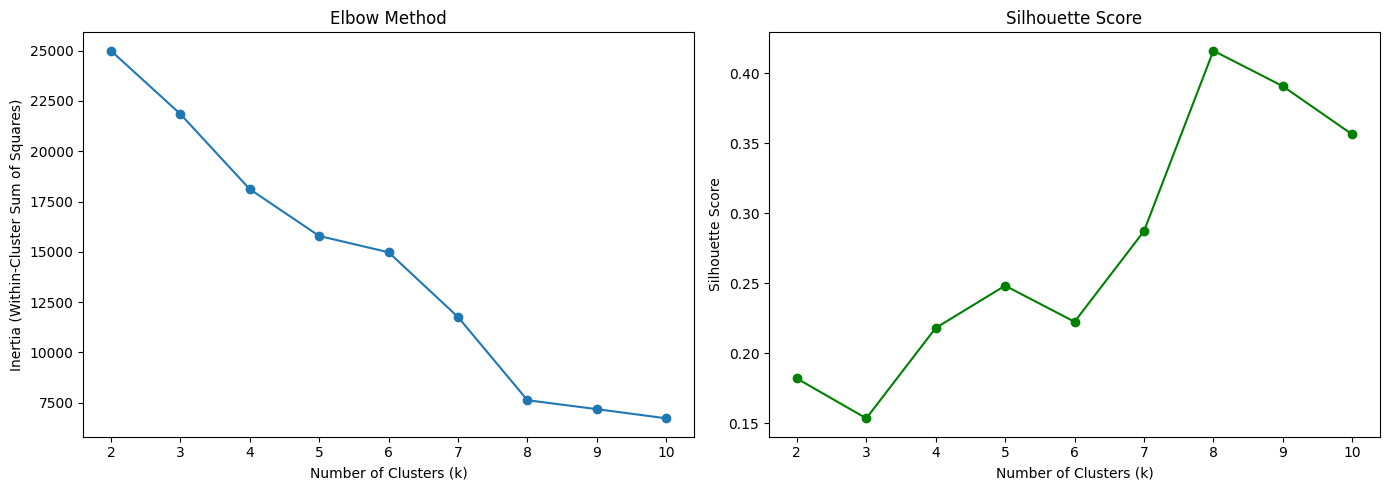

In [ ]:
# 클러스터링에서 적절한 군집수를 결정하기 위해 elbow method 와 silhouette score 활용
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# 1. 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scaled)

# 2. Elbow & Silhouette 시각화
inertias = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)  # inertia: 군집 내 거리 제곱합
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 3. 그래프 그리기
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax[0].plot(K, inertias, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

# Silhouette Score
ax[1].plot(K, silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [ ]:
# 데이터포인터들이 클러스터링 갯수가 8개일 때 가장 잘 분리되는 것으로 보여 8개군으로 가상인물 분류
# 실루엣 스코어가 가장 높은 것은 8로 동일하나 기타 수치의 변화는 확인됨.
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: 실루엣 스코어 = {score:.3f}")

k=2: 실루엣 스코어 = 0.126
k=3: 실루엣 스코어 = 0.175
k=4: 실루엣 스코어 = 0.220
k=5: 실루엣 스코어 = 0.249
k=6: 실루엣 스코어 = 0.306
k=7: 실루엣 스코어 = 0.348
k=8: 실루엣 스코어 = 0.416
k=9: 실루엣 스코어 = 0.386


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 수치형 데이터만 추출
df_numeric = df_scaled.select_dtypes(include='number')

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# 3. KMeans 클러스터링 (k=8)
kmeans = KMeans(n_clusters=8, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(X_scaled)

# 4. 군집별 주요 특성 요약 (평균값 기준)
summary = df_scaled.groupby('cluster').mean(numeric_only=True).round(2)

print("군집별 주요 특성 요약:")
print(summary.iloc[:, :12]) # 앞의 12개 컬럼만 확인


군집별 주요 특성 요약:
         position   age  years_at_company  performance_score  \
cluster                                                        
0            0.00  0.25              0.07               0.47   
1            0.25  0.27              0.20               0.53   
2            0.20  0.33              0.20               0.46   
3            0.53  0.65              0.44               0.52   
4            0.13  0.24              0.13               0.64   
5            0.27  0.36              0.23               0.53   
6            0.13  0.29              0.13               0.42   
7            0.50  0.51              0.43               0.59   

         last_promotion_year  customer_satisfaction_avg  \
cluster                                                   
0                       0.62                       0.50   
1                       0.44                       0.22   
2                       0.60                       0.75   
3                       0.30                      

<ipython-input-42-4f922a94590d>:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.

<ipython-input-43-4473e973a313>:12: UserWarning:

Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.

<ipyt

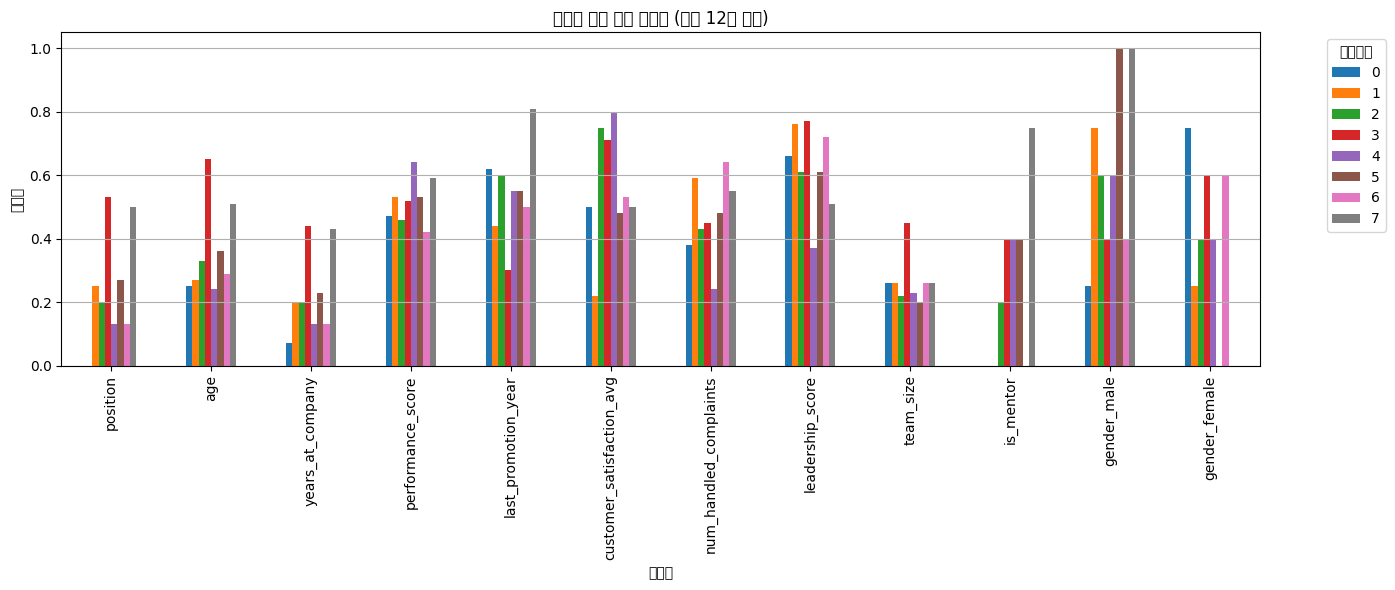

In [ ]:
import matplotlib.pyplot as plt

# 1. 군집별 평균값 (앞의 12개 컬럼만)
summary = df_scaled.groupby('cluster').mean(numeric_only=True).round(2).iloc[:, :12]

# 2. 시각화
summary.T.plot(kind='bar', figsize=(14, 6))
plt.title('군집별 주요 특성 평균값 (상위 12개 컬럼)')
plt.xlabel('특성명')
plt.ylabel('평균값')
plt.legend(title='클러스터', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [ ]:
import plotly.graph_objects as go

# 1. 군집별 평균값 요약 (상위 12개 컬럼만 사용)
summary = df_scaled.groupby('cluster').mean(numeric_only=True).round(2).iloc[:, :12]
categories = summary.columns.tolist()

# 2. Plotly 레이더 차트 생성
fig = go.Figure()

for i in range(summary.shape[0]):  # 각 군집에 대해
    fig.add_trace(go.Scatterpolar(
        r=summary.iloc[i].values.tolist() + [summary.iloc[i].values[0]],  # 닫기용 반복
        theta=categories + [categories[0]],
        fill='toself',
        name=f'Cluster {i}'
    ))

# 3. 레이아웃 설정
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True)
    ),
    title="군집별 주요 특성 Radar Chart (Plotly)",
    showlegend=True,
    width=800,
    height=700
)

# 4. 출력
fig.show()


In [ ]:
import plotly.graph_objects as go

# ▶️ 1. 군집별 요약 (상위 6~12개 특성 사용 가능)
summary = df_scaled.groupby('cluster').mean(numeric_only=True).round(2).iloc[:, :6]  # 원하는 개수 조정 가능
categories = summary.columns.tolist()

# ▶️ 2. 클러스터별로 각각 레이다 차트 생성
for i in range(summary.shape[0]):
    fig = go.Figure()

    values = summary.iloc[i].tolist()
    values += values[:1]  # 닫기용

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=f'Cluster {i}',
        line=dict(width=3),
        marker=dict(size=6)
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[summary.min().min(), summary.max().max()])
        ),
        title=f"📊 Radar Chart - Cluster {i}",
        showlegend=False,
        width=600,
        height=500
    )

    fig.show()


cluster0 -> 향후 성장 가능성이 높은 그룹
- 나이가 어리고, 근속년수도 짧으며, 실적과 고객만족이 중간수준인 그룹

cluster1 -> 실적은 높으나 서비스 마인드가 필요한 그룹
- 나이는 어리나, 근속년수는 cluster0에 비해 길고 실적도 평균이상이나, 고객만족도는 떨어지는 그룹

cluster2 -> 실적은 떨어지나, 고객만족도가 높아 향후 활약이 기대되는 그룹
- 나이는 어리고, 근속년수도 길지 않으나, 고객만족도가 높은 그룹

cluster3 -> 회사의 허리
- 나이 많으며, 근속년수도, 실적도 중간이상이며, 고객만족도가 높은 그룹으로 승진한지 얼마 되지 않은 그룹

cluster4 -> 슈퍼 루키
- 나이도 어리고 근속년수도 짧지만 실적과 고객만족도가 높은 그룹

cluster5 -> 평범
- 나이, 근속년수, 실적, 고개만족도가 모두 중간 수준인 평법한 그룹

cluster6 -> 회사 적응중
- 뒤늦게 회사에 들어온 편으로, 직위는 낮으나 비교적 높은 고객만족도를 보여주는 그룹

cluster7 -> 의욕적인 그룹으로 실력자이나 일부 개선여지 있음
- 나이 많고, 근속년수도 많으며, 직위도 높은 편이며, 높은 실적을 바탕으로 승진한지 얼마 되지 않은 그룹으로, 직위에 비해 고객만족도는 낮은 편으로 개선의 여지가 있다.

In [ ]:
df_scaled.head()

,position,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor,...,col2_emb_375,col2_emb_376,col2_emb_377,col2_emb_378,col2_emb_379,col2_emb_380,col2_emb_381,col2_emb_382,col2_emb_383,cluster
0,0.333333,0.428571,0.214286,0.965517,0.25,1.000000,0.136364,0.868421,0.403333,1.0,...,0.362444,0.564955,0.435083,0.478782,0.383226,0.429031,0.345780,0.656100,0.492882,3
1,0.000000,0.095238,0.071429,0.827586,0.00,0.866667,0.545455,0.712895,0.313333,0.0,...,0.188254,0.155700,0.919237,0.143441,0.636113,0.196602,0.132671,0.207845,0.722072,6
2,0.000000,0.238095,0.000000,0.965517,0.25,0.600000,0.863636,0.661316,0.357778,0.0,...,0.536981,0.513776,0.207432,0.668369,0.826277,0.374747,0.807027,0.261307,0.202562,5
3,0.000000,0.000000,0.071429,0.068966,0.75,1.000000,0.227273,0.605263,0.188889,0.0,...,0.536209,0.353371,0.373743,0.269085,0.235902,0.511039,0.061264,0.824034,0.156498,4
4,0.333333,0.333333,0.285714,0.206897,0.50,0.266667,0.681818,0.500000,0.208889,1.0,...,0.756002,0.929258,0.178823,0.778956,0.552881,0.493006,0.549019,0.567167,0.199991,2


In [ ]:
df.to_excel('clustered_result.xlsx', index=False)

In [ ]:
from google.colab import files
files.download('clustered_result.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving profiles.xlsx to profiles.xlsx


In [ ]:
import pandas as pd

df_original = pd.read_excel('profiles.xlsx')

df_original.head()

,employee_id,name,branch,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,customer_satisfaction_avg,num_handled_complaints,leadership_score,team_size,is_mentor
0,H001,구민준,Tech운영부,대리,중간 관리자,여,34,4,98,2020,5.0,12,93.0,NaN,True
1,H002,김수진,글로벌서비스개발부,행원,실무자,남,27,2,94,2019,4.8,30,NaN,NaN,False
2,H003,김애은,금융서비스개발부,행원,실무자,남,30,1,98,2020,4.4,44,NaN,NaN,False
3,H004,김여리,Tech운영부,행원,실무자,여,25,2,72,2022,5.0,16,NaN,NaN,False
4,H005,김연지,자금세탁방지부,대리,중간 관리자,남,32,5,76,2021,3.9,36,79.0,NaN,True


In [ ]:
# 두 데이터프레임의 순서가 동일하므로 인덱스 기준으로 결합
# 만약 순서가 다르다면 공통 키(예:이름) 기준으로 병합해야 함.
# 순서다른 경우 예시. df_final = df.merge(original_df[['소속', '직위', '이름']], on='이름', how='left')

df_final = pd.concat([df_original, df_scaled], axis=1)
df_final.head()

,employee_id,name,branch,position,position_group,gender,age,years_at_company,performance_score,last_promotion_year,...,col2_emb_375,col2_emb_376,col2_emb_377,col2_emb_378,col2_emb_379,col2_emb_380,col2_emb_381,col2_emb_382,col2_emb_383,cluster
0,H001,구민준,Tech운영부,대리,중간 관리자,여,34,4,98,2020,...,0.362444,0.564955,0.435083,0.478782,0.383226,0.429031,0.345780,0.656100,0.492882,3
1,H002,김수진,글로벌서비스개발부,행원,실무자,남,27,2,94,2019,...,0.188254,0.155700,0.919237,0.143441,0.636113,0.196602,0.132671,0.207845,0.722072,6
2,H003,김애은,금융서비스개발부,행원,실무자,남,30,1,98,2020,...,0.536981,0.513776,0.207432,0.668369,0.826277,0.374747,0.807027,0.261307,0.202562,5
3,H004,김여리,Tech운영부,행원,실무자,여,25,2,72,2022,...,0.536209,0.353371,0.373743,0.269085,0.235902,0.511039,0.061264,0.824034,0.156498,4
4,H005,김연지,자금세탁방지부,대리,중간 관리자,남,32,5,76,2021,...,0.756002,0.929258,0.178823,0.778956,0.552881,0.493006,0.549019,0.567167,0.199991,2


In [ ]:
df_final.to_excel('df_final.xlsx', index=False)
files.download('df_final.xlsx')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>